# Pre Processing 

In [189]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [190]:
## loading libraries essential for feature engineering


In [191]:
# loading the dataset
import joblib
df = joblib.load('/Users/mac/Desktop/Desktop_Files/Projects/Zomato Restaurant Rating Prediction/artifacts/df_EDA_cleaned.pkl')

In [192]:
df.head()

,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost,type,listed_in(city)
0,1,1,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,1,0,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,Banashankari
2,1,0,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet,Banashankari
3,0,0,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet,Banashankari
4,0,0,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet,Banashankari


In [193]:
df = df.drop(columns='cuisines',axis=1)

In [194]:
df.sample(3)

,online_order,book_table,rate,votes,location,rest_type,approx_cost,type,listed_in(city)
9582,0,0,4.2,618,Brigade Road,Cafe,500,Cafes,Church Street
15773,0,0,3.1,6,Old Airport Road,Quick Bites,200,Dine-out,Indiranagar
37673,1,0,4.1,374,Jeevan Bhima Nagar,Quick Bites,150,Dine-out,Old Airport Road


In [195]:
locs = df.location.unique()

col_list = ['online_order', 'book_table', 'location', 'rest_type', 'type', 'listed_in(city)']

for col in col_list:
    feature = df[col].astype('category')
    dict_val = dict(enumerate(feature.cat.categories))
    print(col, dict_val)

online_order {0: 0, 1: 1}
book_table {0: 0, 1: 1}
location {0: 'BTM', 1: 'Banashankari', 2: 'Banaswadi', 3: 'Bannerghatta Road', 4: 'Basavanagudi', 5: 'Basaveshwara Nagar', 6: 'Bellandur', 7: 'Bommanahalli', 8: 'Brigade Road', 9: 'Brookefield', 10: 'CV Raman Nagar', 11: 'Central Bangalore', 12: 'Church Street', 13: 'City Market', 14: 'Commercial Street', 15: 'Cunningham Road', 16: 'Domlur', 17: 'East Bangalore', 18: 'Ejipura', 19: 'Electronic City', 20: 'Frazer Town', 21: 'HBR Layout', 22: 'HSR', 23: 'Hebbal', 24: 'Hennur', 25: 'Hosur Road', 26: 'Indiranagar', 27: 'Infantry Road', 28: 'JP Nagar', 29: 'Jalahalli', 30: 'Jayanagar', 31: 'Jeevan Bhima Nagar', 32: 'KR Puram', 33: 'Kaggadasapura', 34: 'Kalyan Nagar', 35: 'Kammanahalli', 36: 'Kanakapura Road', 37: 'Kengeri', 38: 'Koramangala', 39: 'Koramangala 1st Block', 40: 'Koramangala 2nd Block', 41: 'Koramangala 3rd Block', 42: 'Koramangala 4th Block', 43: 'Koramangala 5th Block', 44: 'Koramangala 6th Block', 45: 'Koramangala 7th Block',

In [196]:
df = df.rename(columns={'listed_in(city)' : 'city'})

In [197]:
df.head()

,online_order,book_table,rate,votes,location,rest_type,approx_cost,type,city
0,1,1,4.1,775,Banashankari,Casual Dining,800,Buffet,Banashankari
1,1,0,4.1,787,Banashankari,Casual Dining,800,Buffet,Banashankari
2,1,0,3.8,918,Banashankari,"Cafe, Casual Dining",800,Buffet,Banashankari
3,0,0,3.7,88,Banashankari,Quick Bites,300,Buffet,Banashankari
4,0,0,3.8,166,Basavanagudi,Casual Dining,600,Buffet,Banashankari


### Categorical Features

In [198]:
# Converting columns to catagorical variables 
def convert_cat(df, col_list): 
  df_temp = pd.DataFrame() 
  df_temp = df
  col_list = col_list
  
  for col in col_list:
      df_temp[col] = df_temp[col].astype('category')
      df_temp[col] = df_temp[col].cat.codes
      
  return df_temp

col_list = ['online_order', 'book_table', 'location', 'rest_type', 'type', 'city']
df_clean = convert_cat(df, col_list)

In [199]:
df_clean.head(2)

,online_order,book_table,rate,votes,location,rest_type,approx_cost,type,city
0,1,1,4.1,775,1,24,800,0,1
1,1,0,4.1,787,1,24,800,0,1


array([[<Axes: title={'center': 'online_order'}>,
        <Axes: title={'center': 'book_table'}>,
        <Axes: title={'center': 'rate'}>],
       [<Axes: title={'center': 'votes'}>,
        <Axes: title={'center': 'location'}>,
        <Axes: title={'center': 'rest_type'}>],
       [<Axes: title={'center': 'approx_cost'}>,
        <Axes: title={'center': 'type'}>,
        <Axes: title={'center': 'city'}>]], dtype=object)

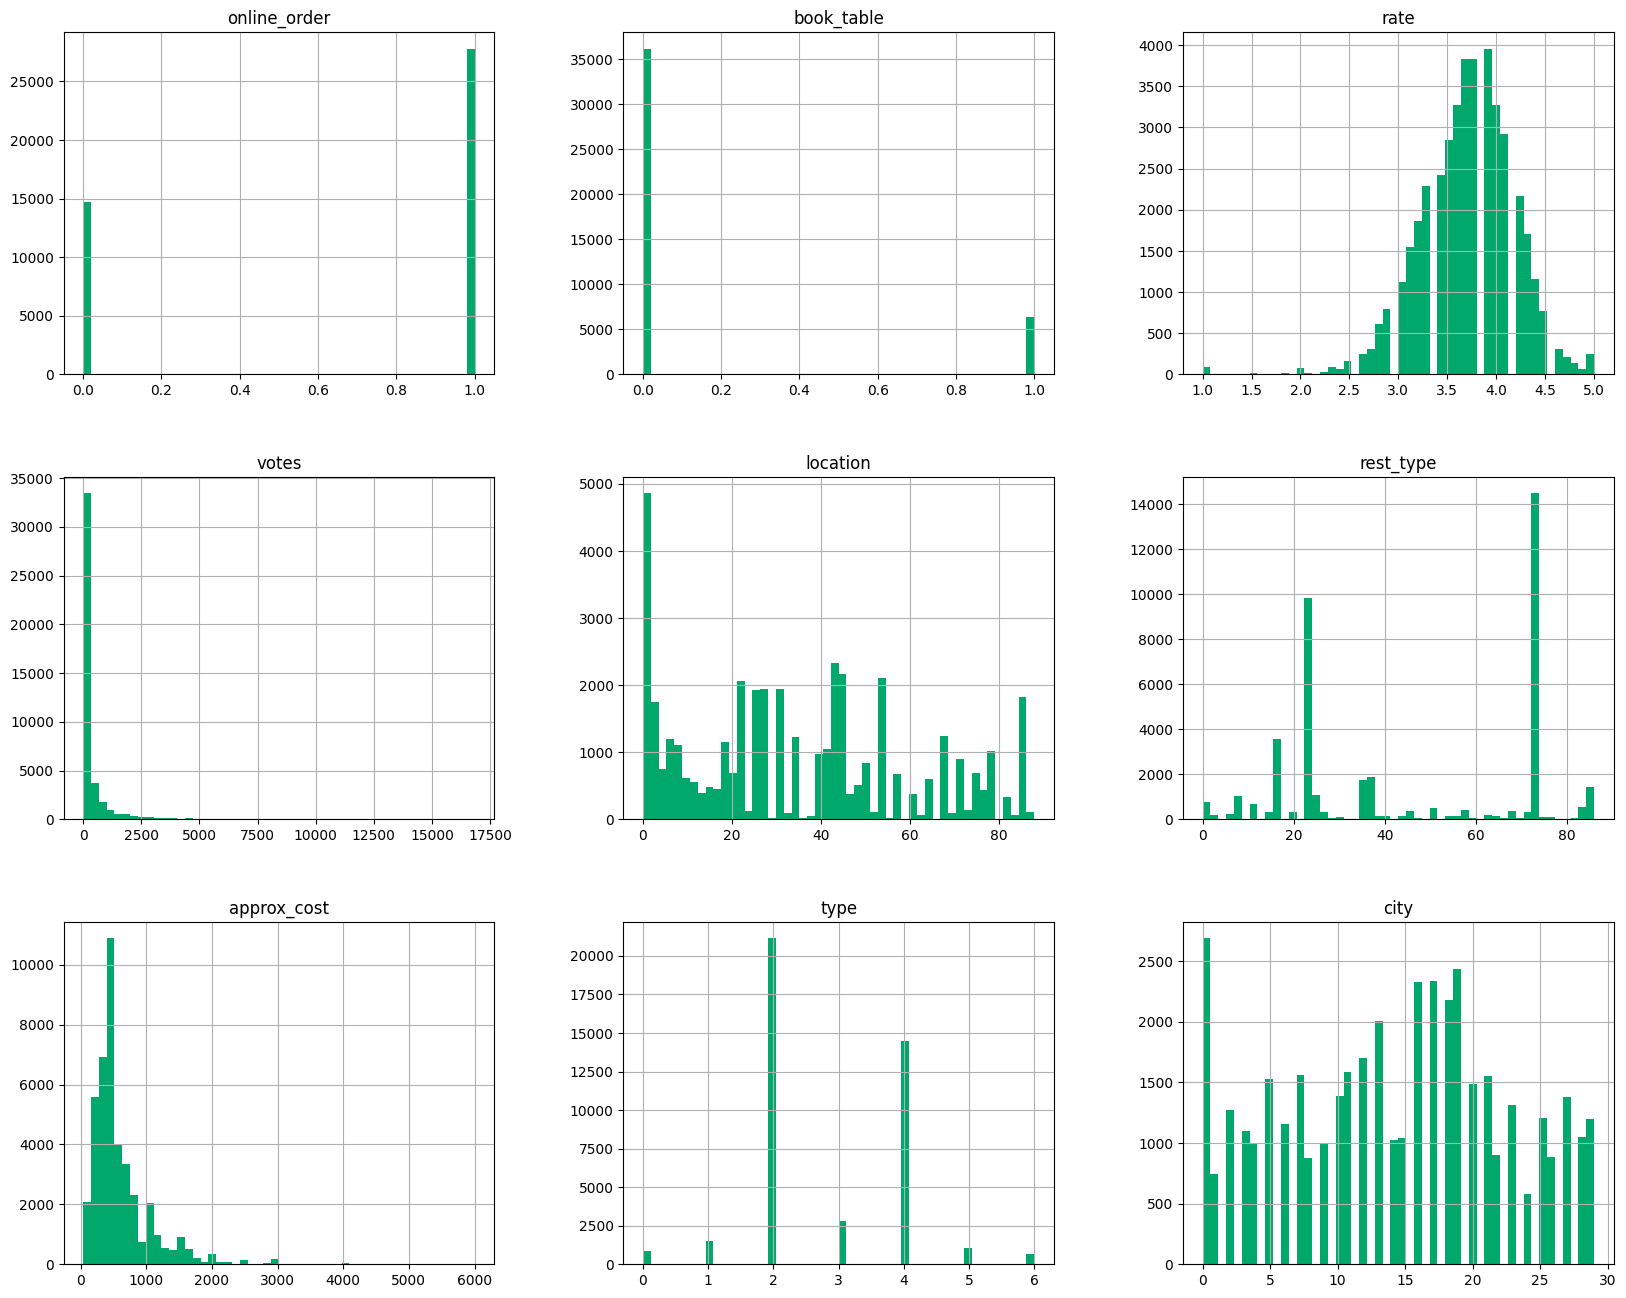

In [200]:
df_clean.hist(bins = 50, figsize=(20,16), color = '#00A86B') 


In [201]:
df_clean.online_order.value_counts()

online_order
1    27804
0    14719
Name: count, dtype: int64

## Outliers Detection

In [202]:
import scipy
import scipy.stats as stats

def outlier_cols(x): 
    n = len(x)
    mean_x = np.mean(x)
    sd_x = np.std(x)
    numerator = max(abs(x-mean_x))
    g_calculated = numerator/sd_x
    t_value = stats.t.ppf(1 - 0.05 / (2 * n), n - 2)
    g_critical = ((n - 1) * np.sqrt(np.square(t_value))) / (np.sqrt(n) * np.sqrt(n - 2 + np.square(t_value)))
    return col if (g_critical) < g_calculated else 0

- Grubbs’ Test is a statistical test used to detect a single outlier in a normally distributed dataset.

- It tests whether the most extreme value (either maximum or minimum) in a dataset is an outlier compared to the rest

In [203]:
cols_with_outliers = []
for col in df_clean.columns:
    outlier_col = outlier_cols(df_clean[col])
    cols_with_outliers.append(outlier_col)

while (cols_with_outliers.count(0)):
    cols_with_outliers.remove(0)
print('Columns with outliers are: {}'.format(cols_with_outliers) )

Columns with outliers are: ['rate', 'votes', 'approx_cost']


### Using EDA Tools:-

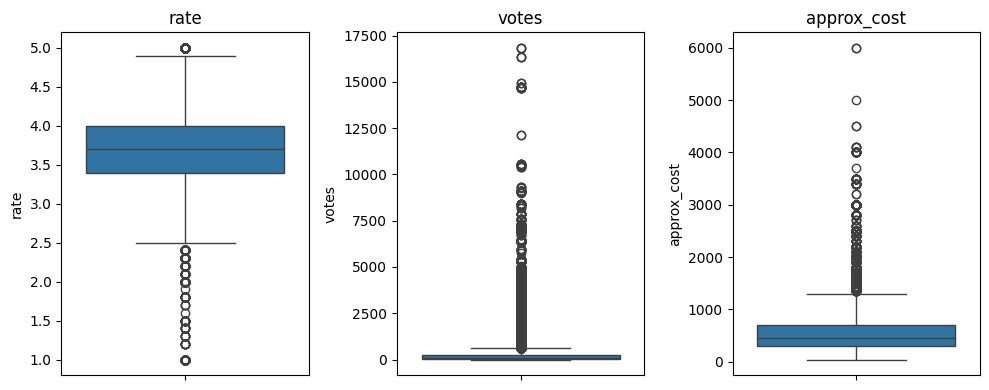

In [204]:

numeric_cols = ['rate', 'votes', 'approx_cost']
plt.figure(figsize=(10,4))
for i, col in enumerate(numeric_cols):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df_clean[col])
    plt.title(col)
plt.tight_layout()
plt.show()


- Clearly, columns = ['rate', 'approx_cost', 'votes'] has outliers 

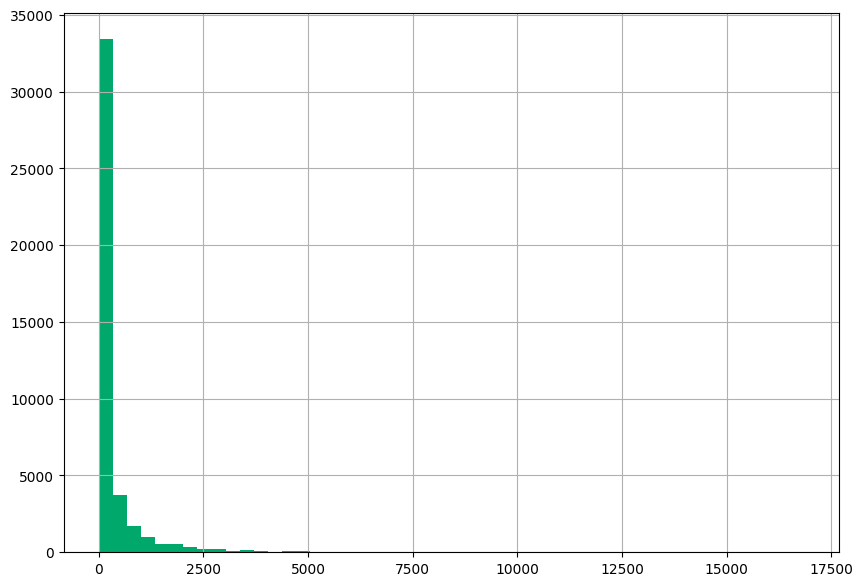

In [205]:
# Plotting histogram
%matplotlib inline
df_clean['votes'].hist(bins = 50, figsize=(10,7), color = '#00A86B') 
plt.show()

In [206]:
def grubbs_test(x):
    n = len(x)
    mean_x = np.mean(x)
    sd_x = np.std(x)
    numerator = max(abs(x-mean_x))
    g_calculated = numerator/sd_x
    print("Grubbs Calculated Value:",g_calculated)
    t_value = stats.t.ppf(1 - 0.05 / (2 * n), n - 2)
    g_critical = ((n - 1) * np.sqrt(np.square(t_value))) / (np.sqrt(n) * np.sqrt(n - 2 + np.square(t_value)))
    print("Grubbs Critical Value:",g_critical)
    if g_critical > g_calculated:
        print("From grubbs_test we observe that calculated value is lesser than critical value, Accept null hypothesis and conclude that there is no outlier\n")
    else:
        print("From grubbs_test we observe that calculated value is greater than critical value, Reject null hypothesis and conclude that there is an outliers\n")

### Handling Outliers

In [207]:
df_clean.head(2)

,online_order,book_table,rate,votes,location,rest_type,approx_cost,type,city
0,1,1,4.1,775,1,24,800,0,1
1,1,0,4.1,787,1,24,800,0,1


#### Votes Column

- Setting up "cap" anything above the 99th percentile:

In [208]:
cut_off = df_clean['votes'].quantile(0.985)
cut_off

np.float64(3485.0)

In [209]:
# Removing outliers
cut_off = cut_off
for i in df_clean['votes']:
    if i >= cut_off:
        df_clean['votes'] = df_clean['votes'].replace(i, cut_off)


- Since the data is skewed, we will apply "log transform" to reduce skewness

In [210]:
df_clean['votes_log'] = np.log1p(df_clean['votes'])

In [211]:
grubbs_test(df_clean['votes'])

Grubbs Calculated Value: 5.06147828607288
Grubbs Critical Value: 4.85902075952334
From grubbs_test we observe that calculated value is greater than critical value, Reject null hypothesis and conclude that there is an outliers



In [212]:
grubbs_test(df_clean['votes_log'])

Grubbs Calculated Value: 2.336110613131968
Grubbs Critical Value: 4.85902075952334
From grubbs_test we observe that calculated value is lesser than critical value, Accept null hypothesis and conclude that there is no outlier



In [213]:
df_clean.head(2)

,online_order,book_table,rate,votes,location,rest_type,approx_cost,type,city,votes_log
0,1,1,4.1,775,1,24,800,0,1,6.654153
1,1,0,4.1,787,1,24,800,0,1,6.669498


- outliers handled in "votes" column

#### Approx_cost column

- same thing, applying log transform here too

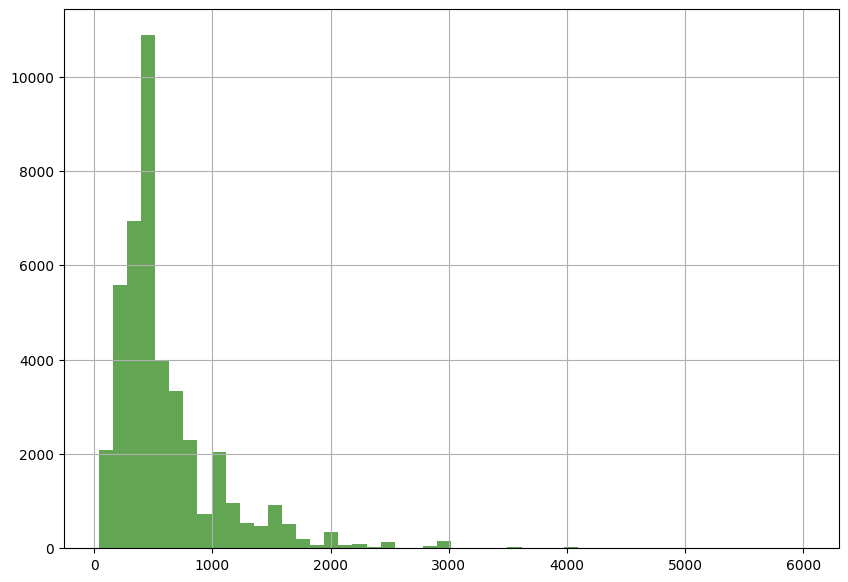

In [214]:
# Plotting histogram
%matplotlib inline
df_clean['approx_cost'].hist(bins = 50, figsize=(10,7), color = "#62A553") 
plt.show()

- setting up "cap" to replace the outliers with the cutoff value
- I'll (as usual) go with "anything above 99th percentile as an outlier" theroy🖐.

In [215]:
cost_cut_off = df_clean['approx_cost'].quantile(0.99)
cost_cut_off

np.float64(2500.0)

In [216]:
# Removing outliers
cut_off = cost_cut_off
for i in df_clean['approx_cost']:
    if i >= cut_off:
        df_clean['approx_cost'] = df_clean['approx_cost'].replace(i, cut_off)



In [217]:
grubbs_test(df_clean['approx_cost'])

Grubbs Calculated Value: 4.3726047942787645
Grubbs Critical Value: 4.85902075952334
From grubbs_test we observe that calculated value is lesser than critical value, Accept null hypothesis and conclude that there is no outlier



In [218]:
df_clean['approx_cost_log'] = np.log1p(df_clean['approx_cost'])

In [219]:
grubbs_test(df_clean['approx_cost_log'])

Grubbs Calculated Value: 3.769124211919514
Grubbs Critical Value: 4.85902075952334
From grubbs_test we observe that calculated value is lesser than critical value, Accept null hypothesis and conclude that there is no outlier



- "approx_cost" columns outliers handled

In [220]:
cols_with_outliers = []
for col in df_clean.columns:
    outlier_col = outlier_cols(df_clean[col])
    cols_with_outliers.append(outlier_col)

while (cols_with_outliers.count(0)):
    cols_with_outliers.remove(0)
print('Columns with outliers are: {}'.format(cols_with_outliers) )

Columns with outliers are: ['rate', 'votes']


In [221]:
def transform_skewed_features(df, cols=None, cap=True, cap_quantile=0.99, plot=True):
    """
    Detects and transforms skewed numeric features using log transformation
    and optional upper-capping of outliers.

    Parameters
    ----------
    df : pandas.DataFrame
        The dataset (e.g., df_clean)
    cols : list
        List of numeric column names to process
    cap : bool, optional
        Whether to cap extreme values before transformation, by default True
    cap_quantile : float, optional
        Quantile threshold for capping, by default 0.99
    plot : bool, optional
        Whether to plot before/after boxplots, by default True

    Returns
    -------
    df : pandas.DataFrame
        The transformed dataset with new log-transformed columns added.
    """

    df = df.copy()

    if cols is None:
        cols = df.select_dtypes(include=[np.number]).columns.tolist()
        print(f"No columns specified, using numeric ones: {cols}")

    # Create figure for before/after comparison
    if plot:
        fig, axes = plt.subplots(2, len(cols), figsize=(5 * len(cols), 6))
        fig.suptitle("Outlier Handling: Before (Top) vs After (Bottom)", fontsize=14)

    for i, col in enumerate(cols):
        if plot:
            sns.boxplot(y=df[col], ax=axes[0, i])
            axes[0, i].set_title(f"{col} (Before)")

        if plot:
            sns.boxplot(y=df[f"{col}_log"], ax=axes[1, i])
            axes[1, i].set_title(f"{col}_log (After)")

    if plot:
        plt.tight_layout()
        plt.show()

    print("✅ Transformation complete.")
    print("New columns created:", [f"{col}_log" for col in cols])

    return df


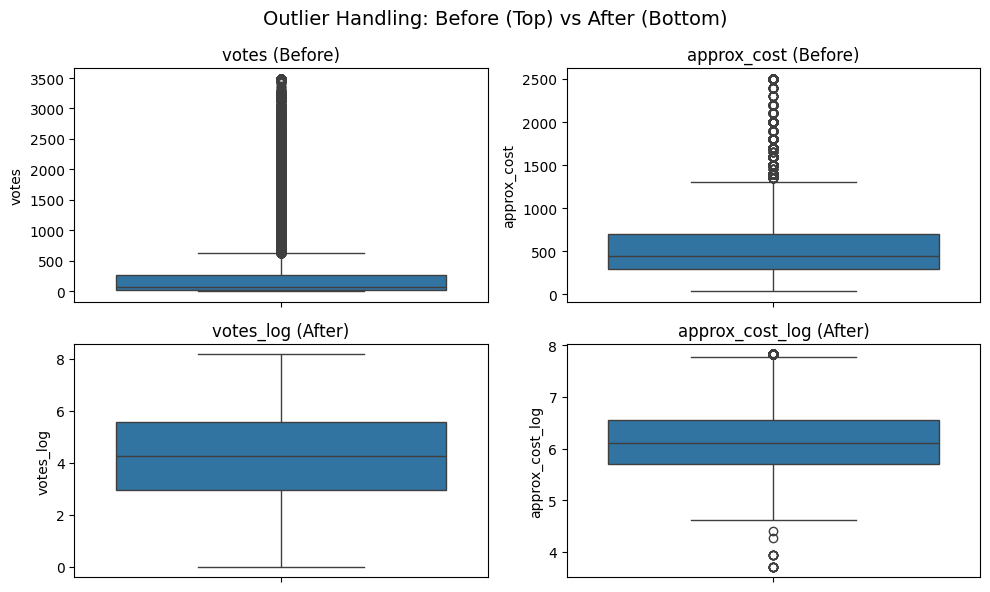

✅ Transformation complete.
New columns created: ['votes_log', 'approx_cost_log']


In [222]:
# Example usage:
df_clean = transform_skewed_features(
    df_clean,
    cols=['votes', 'approx_cost'],  # columns to fix
    cap=True,                      
    cap_quantile=0.99,              # used 99th percentile as cap
    plot=True                       # show boxplots
)


### Rate column

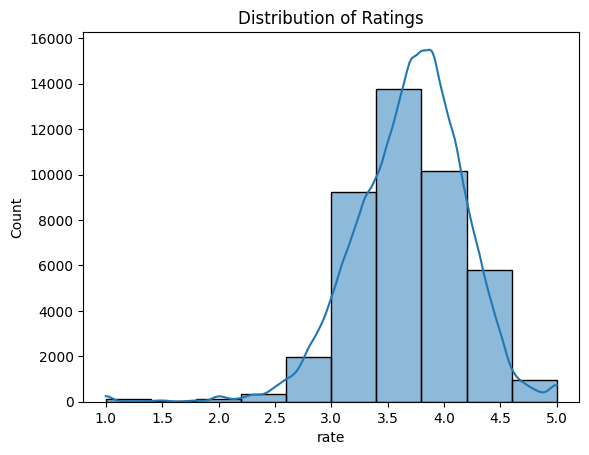

In [223]:
sns.histplot(df_clean['rate'], bins=10, kde=True)
plt.title('Distribution of Ratings')
plt.show()

- we see a right-skewed distribution with peaks near 3.5–4.5 and a small tail near 1–2.
Those low-end points are real, valid low ratings, not bad data.

In [224]:
df_clean['rate_log'] = np.log1p(df_clean['rate'])

In [225]:
grubbs_test(df_clean['rate'])

Grubbs Calculated Value: 5.549945004251305
Grubbs Critical Value: 4.85902075952334
From grubbs_test we observe that calculated value is greater than critical value, Reject null hypothesis and conclude that there is an outliers



- this shows the true varaition of the rating data, we will keep it as it is

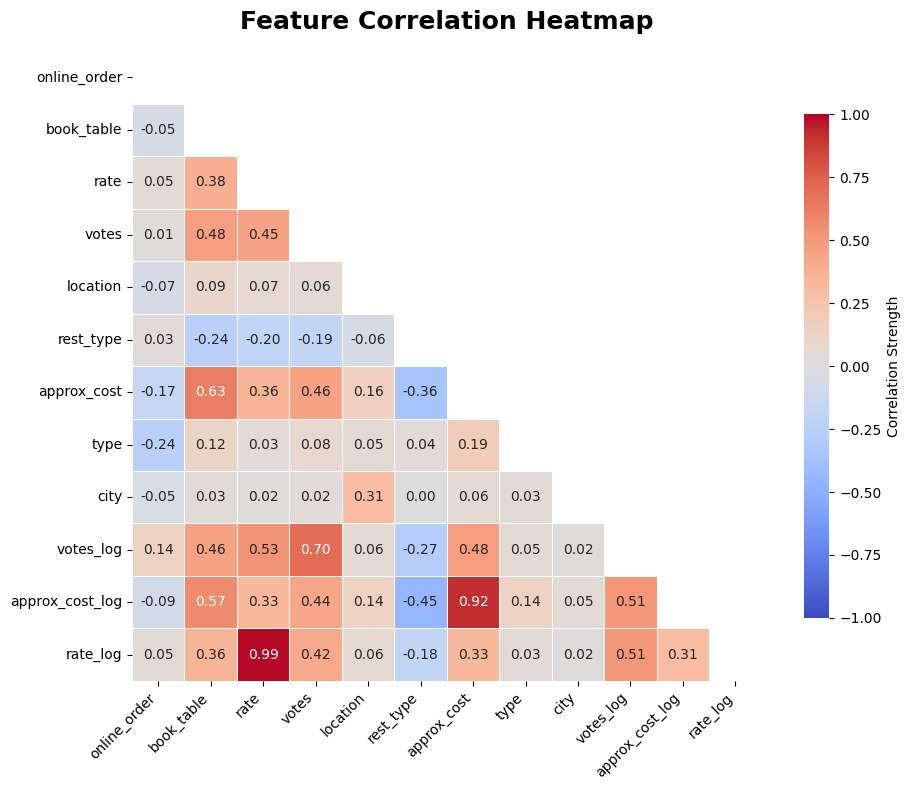

In [227]:
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(df_clean.corr())

sns.heatmap(df_clean.corr(), mask=mask, annot=True, fmt='.2f', square=True,
            cmap='coolwarm', vmin=-1, vmax=1, center=0, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation Strength'}, ax=ax)

ax.set_title('Feature Correlation Heatmap', fontsize=18, fontweight='bold', pad=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()
